In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

In [102]:
df = pd.read_csv('IDTA.csv')
print("First 5 rows:")
print(df.head())
print("\nColumns:", df.columns.tolist())

First 5 rows:
   Gender  Age  Work Pressure  Job Satisfaction Sleep Duration Dietary Habits  \
0  Female   37              2                 4      7-8 hours       Moderate   
1    Male   60              4                 3      5-6 hours      Unhealthy   
2  Female   42              2                 3      5-6 hours       Moderate   
3  Female   44              3                 5      7-8 hours        Healthy   
4    Male   48              4                 3      7-8 hours       Moderate   

  Have you ever had suicidal thoughts ?  Work Hours  Financial Stress  \
0                                    No           6                 2   
1                                   Yes           0                 4   
2                                    No           0                 2   
3                                   Yes           1                 2   
4                                   Yes           6                 5   

  Family History of Mental Illness Depression  
0           

In [103]:

X_cluster = df.drop(['Depression'], axis=1)

In [104]:
from sklearn.preprocessing import LabelEncoder
categorical_cols = [
    'Gender',
    'Sleep Duration',
    'Dietary Habits',
    'Have you ever had suicidal thoughts ?',
    'Family History of Mental Illness'
]


le = LabelEncoder()
for col in categorical_cols:
    X_cluster[col] = le.fit_transform(X_cluster[col])

In [105]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [106]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[-0.29713453, -0.9097285 ],
       [ 1.56903435,  1.63042775],
       [ 0.73177886, -0.51423369],
       ...,
       [-0.00314384,  0.48461965],
       [-0.38269465, -0.27480232],
       [-0.34812852,  0.30746944]])

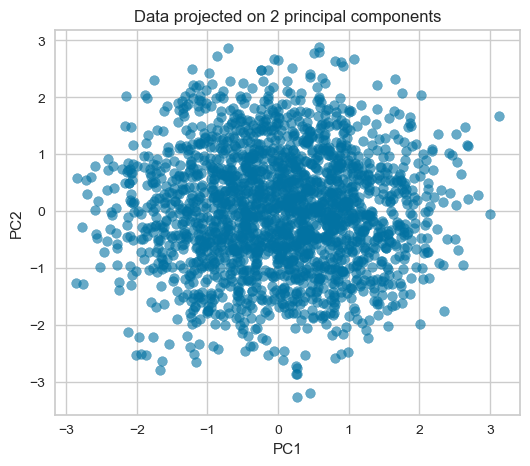

In [107]:
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
plt.title("Data projected on 2 principal components")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()

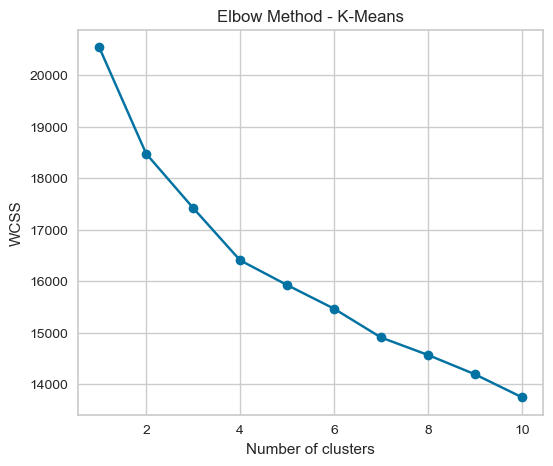

In [108]:
from sklearn.metrics import silhouette_score


wcss = []
for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=0
    )
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method - K-Means")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()




In [109]:
from yellowbrick.cluster import SilhouetteVisualizer
for i in range(2,6):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        max_iter=300,
        n_init=60,
       
    )
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(f"For n_clusters = {i}, the average silhouette_score is : {silhouette_avg}")




For n_clusters = 2, the average silhouette_score is : 0.1024200351698073
For n_clusters = 3, the average silhouette_score is : 0.08549163513698176
For n_clusters = 4, the average silhouette_score is : 0.11059800292647408
For n_clusters = 5, the average silhouette_score is : 0.0929331476121117


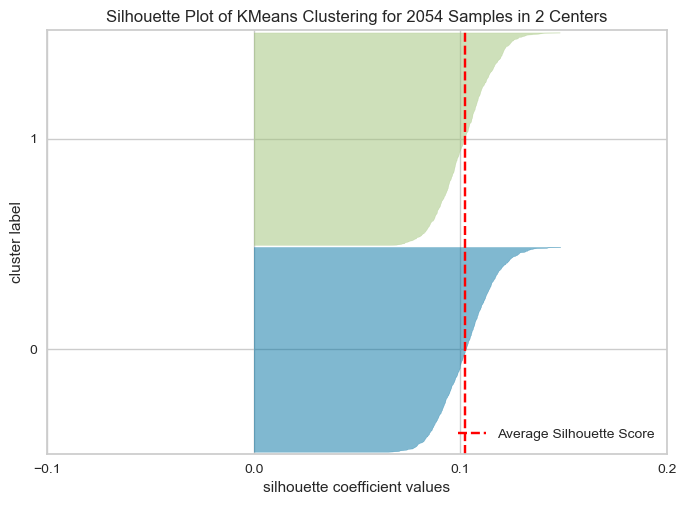

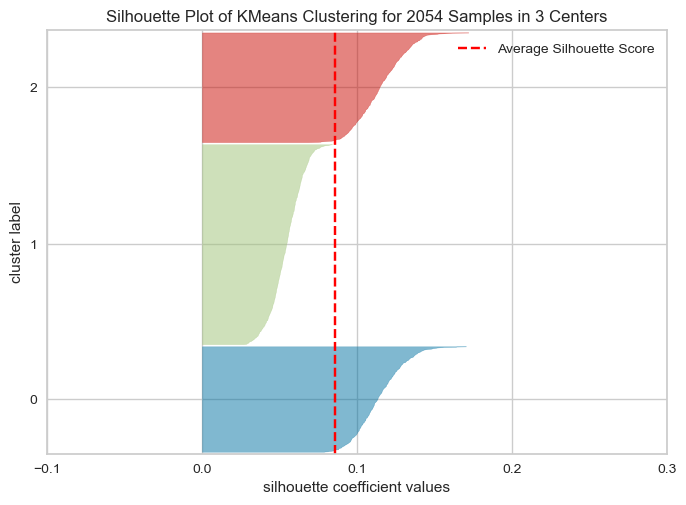

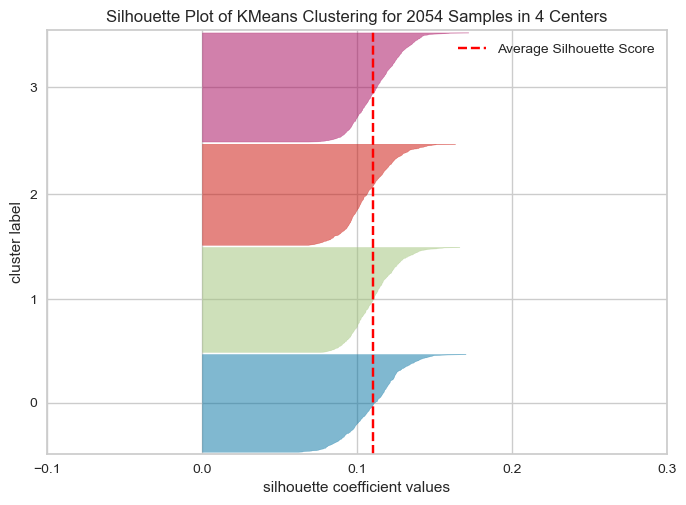

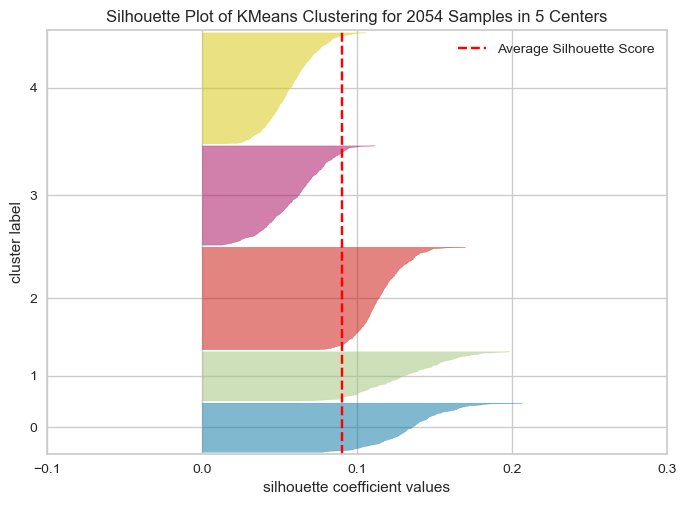

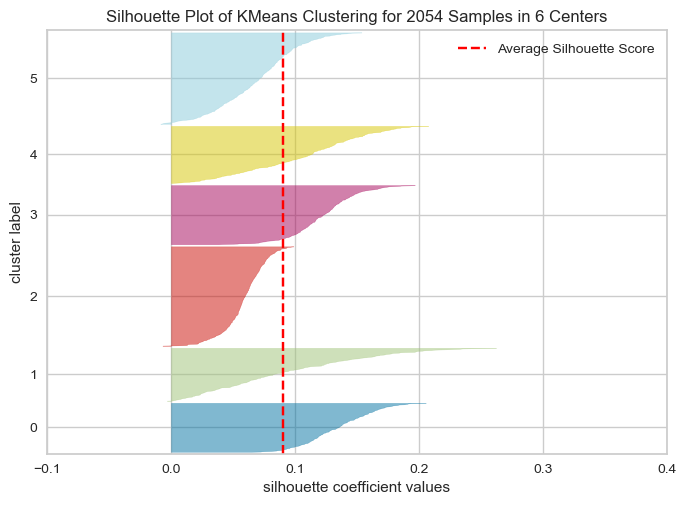

In [110]:
for i in range(2,7):
    visualizer = SilhouetteVisualizer(KMeans(n_clusters=i, n_init=60), colors='yellowbrick')
    visualizer.fit(X_scaled)    # Fit the data to the visualizer
    visualizer.poof()           # Draw/show/poof the data
    plt.show()

In [111]:
optimal_k = 4

kmeans_final = KMeans(n_clusters=optimal_k,max_iter=300,n_init=60, random_state=0)
kmeans_labels = kmeans_final.fit_predict(X_scaled)


df['KMeans_Cluster'] = kmeans_labels


kmeans_silhouette = silhouette_score(X_scaled, kmeans_labels)
print(f"Silhouette Score for K-Means (k=2): {kmeans_silhouette:.3f}")

Silhouette Score for K-Means (k=2): 0.111


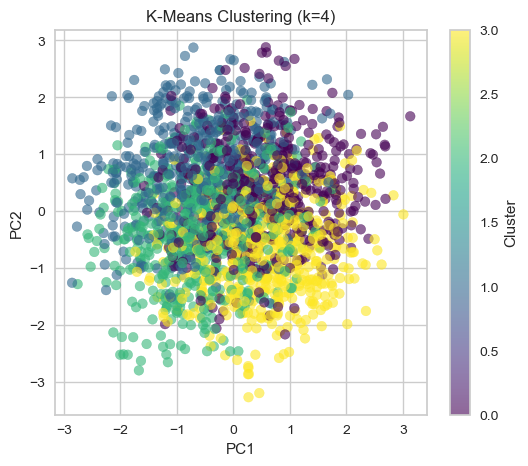

In [112]:
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='viridis', alpha=0.6)
plt.title(f"K-Means Clustering (k={optimal_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

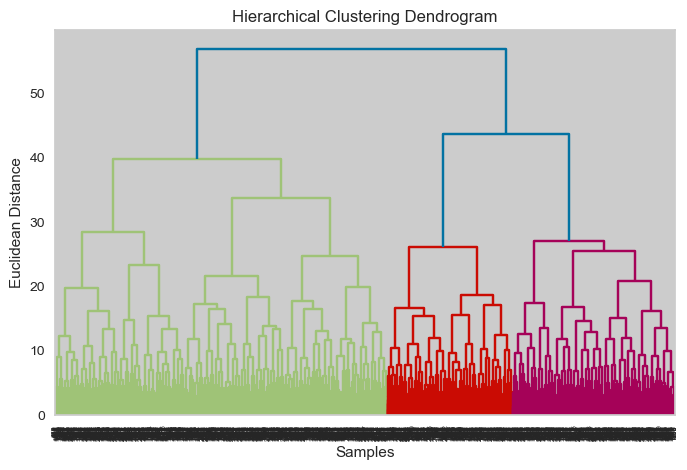

In [113]:
import scipy.cluster.hierarchy as sch
plt.figure(figsize=(8, 5))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Samples")
plt.ylabel("Euclidean Distance")
plt.show()

In [114]:
hier_cluster = AgglomerativeClustering(
    n_clusters=optimal_k,
    metric='euclidean',
    linkage='ward'
)
hier_labels = hier_cluster.fit_predict(X_scaled)


df['Hier_Cluster'] = hier_labels

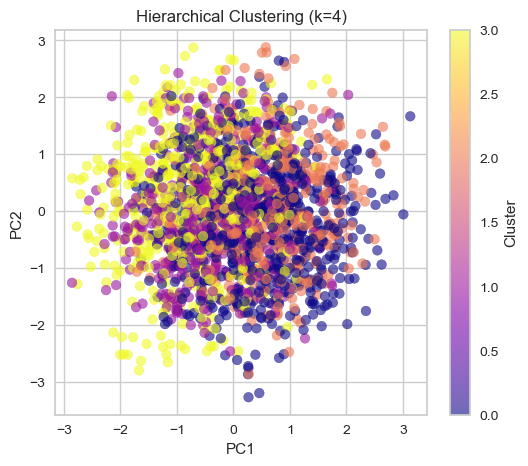

In [115]:
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hier_labels, cmap='plasma', alpha=0.6)
plt.title(f"Hierarchical Clustering (k={optimal_k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label='Cluster')
plt.grid(True)
plt.show()

In [116]:
print("\nK-Means Cluster Summary (numeric features):")
print(df.groupby('KMeans_Cluster').mean(numeric_only=True))

print("\nHierarchical Cluster Summary (numeric features):")
print(df.groupby('Hier_Cluster').mean(numeric_only=True))


K-Means Cluster Summary (numeric features):
                      Age  Work Pressure  Job Satisfaction  Work Hours  \
KMeans_Cluster                                                           
0               41.733598       3.077535          2.974155    5.743539   
1               43.160494       2.897119          2.983539    6.137860   
2               41.484674       3.009579          3.007663    5.959770   
3               42.353591       3.093923          3.088398    5.891344   

                Financial Stress  Hier_Cluster  
KMeans_Cluster                                  
0                       3.029821      0.799205  
1                       2.942387      1.855967  
2                       2.929119      2.051724  
3                       3.011050      0.913444  

Hierarchical Cluster Summary (numeric features):
                    Age  Work Pressure  Job Satisfaction  Work Hours  \
Hier_Cluster                                                           
0             41.55803